Sedang melakukan resampling SMOTE-ENN... Mohon tunggu.
--- VISUALISASI DATA MODEL: DECISION TREE ---


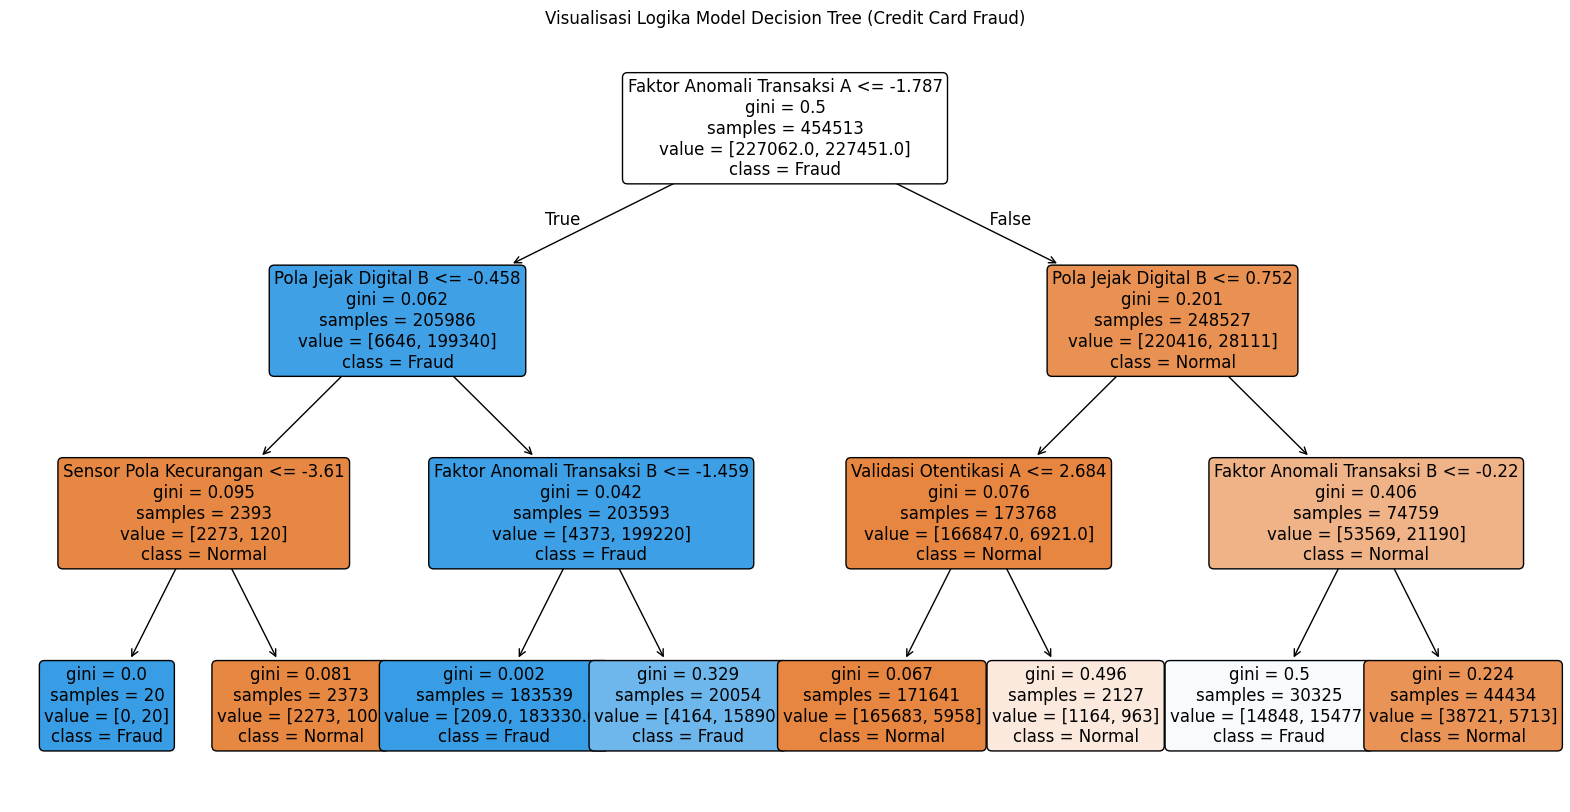

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from imblearn.combine import SMOTEENN

"""
=============================================================================
DOKUMENTASI MODEL DATA: DETEKSI FRAUD KARTU KREDIT
=============================================================================
1. SUMBER DATA: Fitur V1-V28 adalah hasil PCA (Principal Component Analysis)
   untuk privasi, sedangkan 'Amount' adalah nilai transaksi asli.
2. TARGET: Kolom 'Class' (0 = Transaksi Normal, 1 = Transaksi Fraud).
3. MASALAH: Dataset bersifat 'Imbalanced' (Fraud jauh lebih sedikit).
4. SOLUSI: Menggunakan SMOTE-ENN untuk menyeimbangkan jumlah data.
=============================================================================
"""

# --- ALUR 1: PENGAMBILAN & PEMBERSIHAN DATA ---
try:
    # Membaca file CSV dari direktori lokal
    df = pd.read_csv('creditcard.csv')
except FileNotFoundError:
    print("Error: File creditcard.csv tidak ditemukan!")
    df = pd.DataFrame() 

if not df.empty:
    # Menghapus kolom 'Time' karena tidak memiliki korelasi linear yang kuat terhadap target
    df = df.drop(columns=['Time'])
    X = df.drop('Class', axis=1) # Fitur-fitur pendukung
    y = df['Class']              # Label target

    # --- ALUR 2: NORMALISASI DATA ---
    # Mengubah skala fitur 'Amount' agar rata-rata 0 dan varians 1 (Standardization)
    # Hal ini penting agar model tidak terdistraksi oleh nilai nominal uang yang besar.
    scaler = StandardScaler()
    X.loc[:, 'Amount'] = scaler.fit_transform(X[['Amount']])

    # Membagi data menjadi Data Latih (80%) dan Data Uji (20%)
    # 'stratify=y' memastikan proporsi kelas fraud tetap seimbang di kedua data.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # --- ALUR 3: PENANGANAN DATA TIDAK SEIMBANG (RESAMPLING) ---
    # SMOTE-ENN bekerja dengan:
    # 1. SMOTE: Menambah data buatan pada kelas minoritas (Fraud).
    # 2. ENN: Menghapus data yang dianggap 'noise' atau tumpang tindih.
    print("Sedang melakukan resampling SMOTE-ENN... Mohon tunggu.")
    sme = SMOTEENN(random_state=42)
    X_res, y_res = sme.fit_resample(X_train, y_train)

    # --- ALUR 4: PELATIHAN MODEL (DECISION TREE) ---
    # Membangun pohon keputusan. Max_depth=3 dibatasi agar model tidak 'Overfit'
    # (terlalu menghafal data) dan agar visualisasi tetap mudah dibaca.
    dt_model = DecisionTreeClassifier(random_state=42, max_depth=3)
    dt_model.fit(X_res, y_res)

    # --- ALUR 5: VISUALISASI MODEL ---
    print("--- VISUALISASI DATA MODEL: DECISION TREE ---")
    
    # Menampilkan diagram pohon untuk melihat bagaimana model mengambil keputusan
    # (Misal: Jika V17 < -2.5, maka kemungkinan besar adalah Fraud)
    plt.figure(figsize=(20, 10))
    plot_tree(dt_model, 
              feature_names=X.columns,  
              class_names=['Normal', 'Fraud'],
              filled=True, 
              rounded=True,
              fontsize=12) 
    
    plt.title("Visualisasi Logika Model Decision Tree (Credit Card Fraud)")
    plt.show()

Sedang melatih model Random Forest... Mohon tunggu.

--- VISUALISASI DATA MODEL: RANDOM FOREST (FEATURE IMPORTANCE) ---


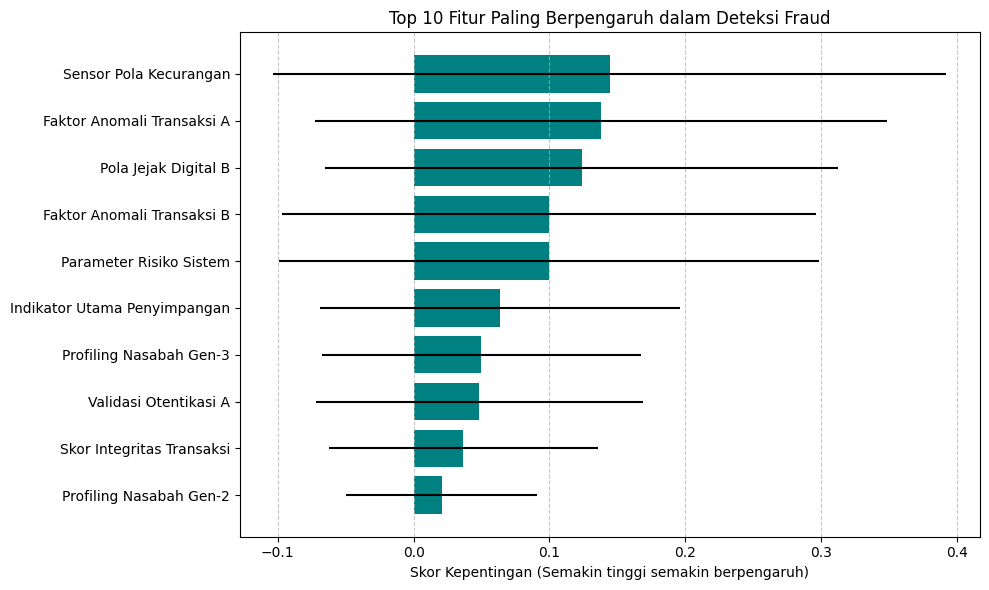

In [12]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

"""
=============================================================================
DOKUMENTASI MODEL DATA: RANDOM FOREST (ENSEMBLE LEARNING)
=============================================================================
1. METODE: Random Forest bekerja dengan membuat 100 pohon keputusan (n_estimators)
   secara acak dan mengambil suara terbanyak (voting) untuk hasil akhir.
2. TUJUAN: Mengurangi risiko overfitting dan memberikan hasil yang lebih stabil
   dibandingkan satu pohon keputusan tunggal.
3. OUTPUT: Memberikan informasi 'Feature Importance' (Fitur paling berpengaruh).
=============================================================================
"""

# --- ALUR 1: KONFIGURASI & PELATIHAN MODEL ---
# n_jobs=-1 digunakan untuk mempercepat proses dengan menggunakan semua inti prosesor komputer.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
print("Sedang melatih model Random Forest... Mohon tunggu.")
rf_model.fit(X_res, y_res)

print("\n--- VISUALISASI DATA MODEL: RANDOM FOREST (FEATURE IMPORTANCE) ---")

# --- ALUR 2: EKSTRAKSI KEPENTINGAN FITUR ---
# Model menghitung seberapa besar pengaruh setiap variabel (V1-V28, Amount) 
# terhadap keputusan apakah sebuah transaksi dianggap Fraud atau Normal.
importances = rf_model.feature_importances_

# Menghitung standar deviasi untuk melihat variabilitas antar pohon (opsional untuk akurasi visual)
std = np.std([tree.feature_importances_ for tree in rf_model.estimators_], axis=0)

# Mengurutkan fitur dari yang paling rendah ke yang paling tinggi, lalu ambil 10 teratas
indices = np.argsort(importances)[-10:] 

# --- ALUR 3: VISUALISASI HASIL ---
# Grafik ini membantu tim analis memahami variabel mana yang harus diawasi ketat.
plt.figure(figsize=(10, 6))
plt.title('Top 10 Fitur Paling Berpengaruh dalam Deteksi Fraud')

# Membuat grafik batang horizontal
plt.barh(range(len(indices)), importances[indices], 
         color='teal', # Mengganti warna agar beda dengan DT
         xerr=std[indices], 
         align='center')

# Memberikan nama fitur pada sumbu Y
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Skor Kepentingan (Semakin tinggi semakin berpengaruh)')
plt.grid(axis='x', linestyle='--', alpha=0.7) # Menambahkan grid agar lebih mudah dibaca

plt.tight_layout()
plt.show()

Sedang melatih model K-NN... Mohon tunggu.

--- VISUALISASI 1: SEBARAN DATA (PCA) ---


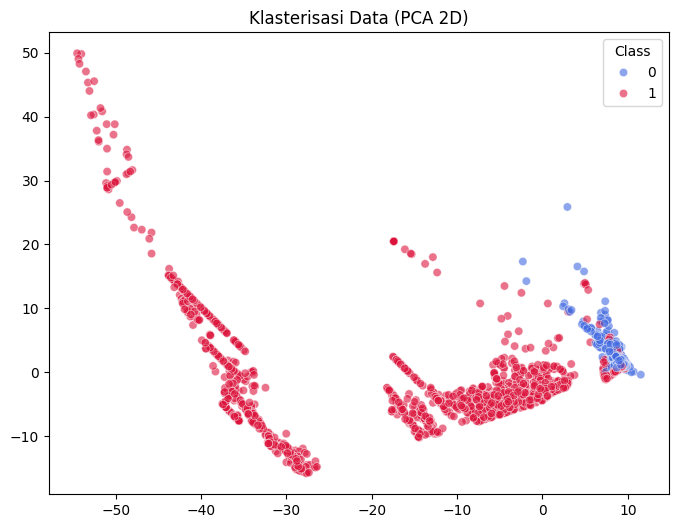

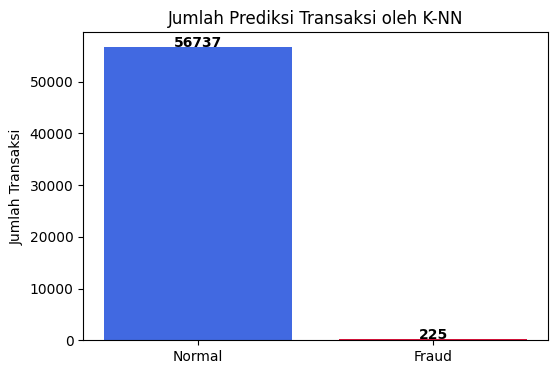

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

"""
=============================================================================
DOKUMENTASI MODEL DATA: K-NEAREST NEIGHBORS (K-NN) & EVALUASI
=============================================================================
1. METODE K-NN: Mengklasifikasikan data berdasarkan 5 tetangga terdekat.
2. PCA VISUAL: Menyederhanakan 28 dimensi menjadi 2D untuk melihat klaster data.
3. CONFUSION MATRIX: Grafik kotak/batang yang menunjukkan akurasi prediksi.
   - True Negative (TN): Normal terdeteksi Normal.
   - True Positive (TP): Fraud terdeteksi Fraud (Paling Penting!).
=============================================================================
"""

# --- ALUR 1: PELATIHAN & PREDIKSI ---
knn_model = KNeighborsClassifier(n_neighbors=5)
print("Sedang melatih model K-NN... Mohon tunggu.")
knn_model.fit(X_res, y_res)

# Melakukan prediksi pada data uji untuk evaluasi
y_pred = knn_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# --- ALUR 2: VISUALISASI KLASTER (PCA) ---
print("\n--- VISUALISASI 1: SEBARAN DATA (PCA) ---")
pca = PCA(n_components=2)
X_res_subset = X_res.sample(5000, random_state=42)
y_res_subset = y_res.loc[X_res_subset.index]
X_pca = pca.fit_transform(X_res_subset)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_res_subset, 
                palette={0: 'royalblue', 1: 'crimson'}, alpha=0.6)
plt.title('Klasterisasi Data (PCA 2D)')
plt.show()

# --- ALUR 4: GRAFIK BATANG PERBANDINGAN (OPSIONAL) ---
# Membuat grafik batang sederhana untuk melihat jumlah prediksi
labels = ['Normal', 'Fraud']
counts = [np.sum(y_pred == 0), np.sum(y_pred == 1)]

plt.figure(figsize=(6, 4))
plt.bar(labels, counts, color=['royalblue', 'crimson'])
plt.title('Jumlah Prediksi Transaksi oleh K-NN')
plt.ylabel('Jumlah Transaksi')
for i, v in enumerate(counts):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.show()

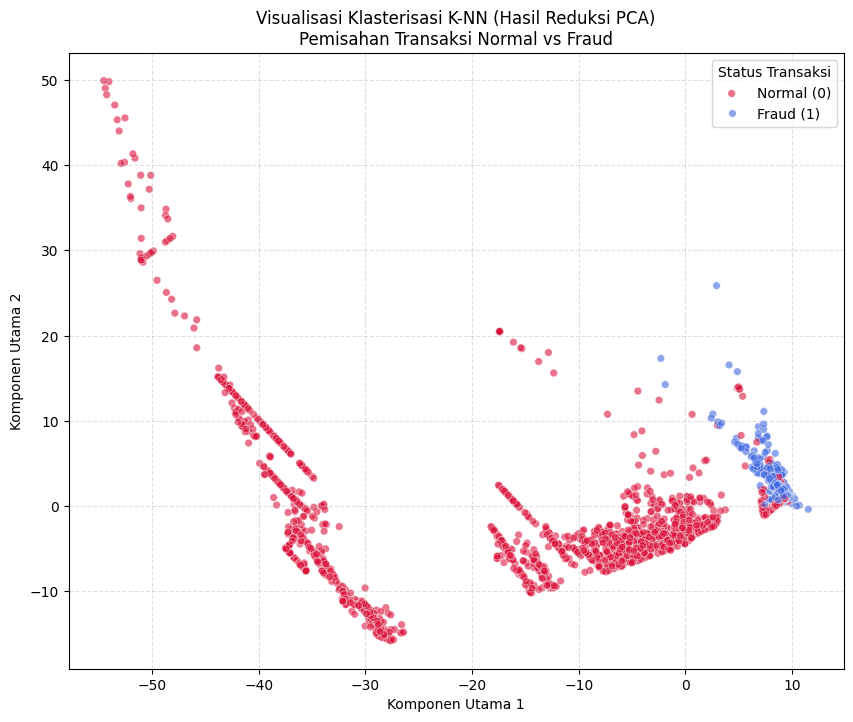

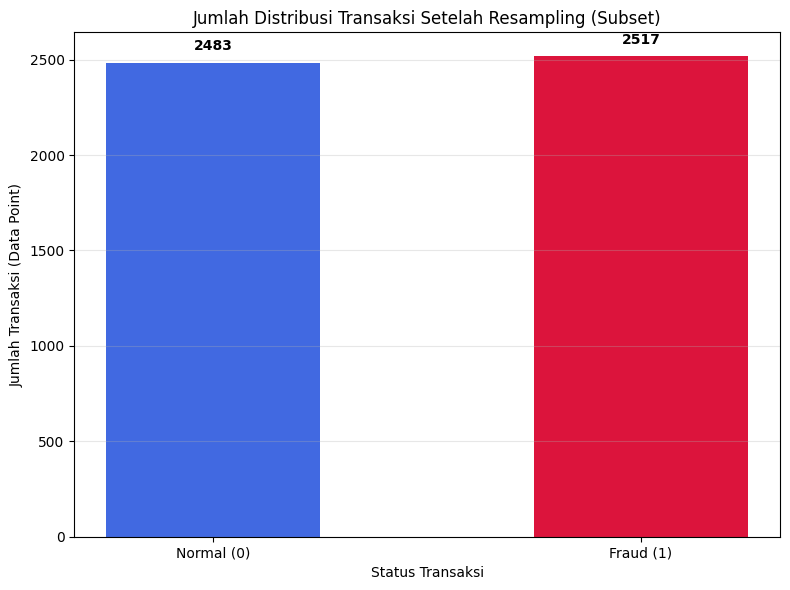

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Pastikan pandas diimpor

# ... (Kode pelatihan model dan PCA tetap sama seperti sebelumnya) ...

# --- ALUR 3: PLOTTING SCATTER (PCA) ---
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_res_subset, 
                palette={0: 'royalblue', 1: 'crimson'}, 
                alpha=0.6, s=30, edgecolor='w')
plt.title('Visualisasi Klasterisasi K-NN (Hasil Reduksi PCA)\nPemisahan Transaksi Normal vs Fraud')
plt.xlabel('Komponen Utama 1')
plt.ylabel('Komponen Utama 2')
plt.legend(title='Status Transaksi', labels=['Normal (0)', 'Fraud (1)'])
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# --- ALUR 4: TAMBAHAN DIAGRAM BATANG (SEPERTI GAMBAR CONTOH) ---
# Menghitung jumlah masing-masing kategori
counts = y_res_subset.value_counts().sort_index()
labels = ['Normal (0)', 'Fraud (1)']

plt.figure(figsize=(8, 6))

# Membuat diagram batang
bars = plt.bar(labels, counts, color=['royalblue', 'crimson'], width=0.5)

# Meniru gaya visual gambar contoh (grid horizontal dan label)
plt.title('Jumlah Distribusi Transaksi Setelah Resampling (Subset)', fontsize=12)
plt.ylabel('Jumlah Transaksi (Data Point)')
plt.xlabel('Status Transaksi')
plt.grid(axis='y', linestyle='-', alpha=0.3)

# Menambahkan angka di atas batang agar lebih informatif
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()